# VarDyn-SW WHIRLS run
This notebook runs the VarDyn-SW configuration for the WHIRLS Agulhas experiment, from setup through assimilation and diagnostics.


Select the GPU device that JAX/CUDA should use for this notebook session.


In [1]:
import os 
NUM_GPU = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = NUM_GPU

Point the notebook to the WHIRLS VarDyn-QG configuration file.


In [2]:
path_config = 'config_VarDyn-SW.py'

Add the local VarDyn mapping package to sys.path so the src modules can be imported from the notebook.


In [3]:
import sys
sys.path.append('/home/flo/VarDyn/mapping')

Load and merge the experiment configuration with the VarDyn defaults.


In [4]:
from src import exp
config = exp.Exp(path_config)

name_experiment: VarDyn-SW
name_exp_save: VarDyn-SW
path_save: ./outputs/VarDyn-SW
tmp_DA_path: ./scratch/VarDyn-SW
init_date: 2025-06-01 00:00:00
final_date: 2025-07-01 00:00:00
assimilation_time_step: 6:00:00
saveoutput_time_step: 6:00:00
flag_plot: 1
write_obs: True
path_obs: ./obs
compute_obs: True
saveoutputs: True
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None

NAME_DIAG is not set in the configuration file


Build the model grid and state object, then display the land/sea mask as a quick geometry check.


In [5]:
from src import state as state
State = state.State(config)

super: GRID_GEO
lon_min: 0
lon_max: 50.0
lat_min: -45.0
lat_max: -20.0
dlon: 0.1
dlat: 0.1
name_init_mask: /data1/data/obs/level4/MDT/mdt_hybrid_cnes_cls22_cmems2020_global.nc
name_var_mask: {'lon': 'longitude', 'lat': 'latitude', 'var': 'mdt'}



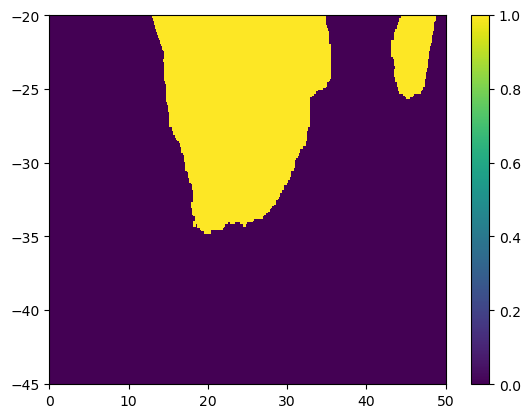

In [6]:
import matplotlib.pylab as plt
plt.pcolormesh(State.lon, State.lat,State.mask)
plt.colorbar()

Instantiate the dynamical model selected by the configuration. 

Reading the boundary condition files might take few minutes...


super: MOD_QGSW
name_class: sw
name_var: {'U': 'u', 'V': 'v', 'SSH': 'sla', 'SST': 'sst'}
name_init_var: {}
var_to_save: None
name_params: ['H']
nl: 1
dtmodel: 900
f0: None
constant_f: False
c0: 2.7
filec_aux: ../../aux_files/aux_first_baroclinic_speed.nc
name_var_c: {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}
cmin: None
cmax: None
H: None
constant_H: False
g_prime: None
init_from_bc: True
cfl: 0.1
bottom_drag_coef: 0
slip_coef: 1.0
taux: 0.0
tauy: 0.0
path_mdt: /data1/data/obs/level4/MDT/mdt_hybrid_cnes_cls22_cmems2020_global.nc
name_var_mdt: {'lon': 'longitude', 'lat': 'latitude', 'var': 'mdt'}
name_var_mdu: {'lon': '', 'lat': '', 'var': ''}
name_var_mdv: {'lon': '', 'lat': '', 'var': ''}
dist_sponge_bc: 150
use_sponge_on_coast: True
sponge_coef: 0.05
tangential_sponge_factor: 1.0
mask_sponge_bc: False
qg_balanced_sponge_bc: False
visc_coef: 150
H_floor: None
H_min: None
H_max: None
diff_coef: 150
diff_coef_trac: 150
time_scheme: rk2
h_adv_scheme: linear_upwind5
mom_adv_scheme: upwind5

/home/flo/VarDyn/mapping/src/mod.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  _ds = xr.open_mfdataset(config_bc.file)


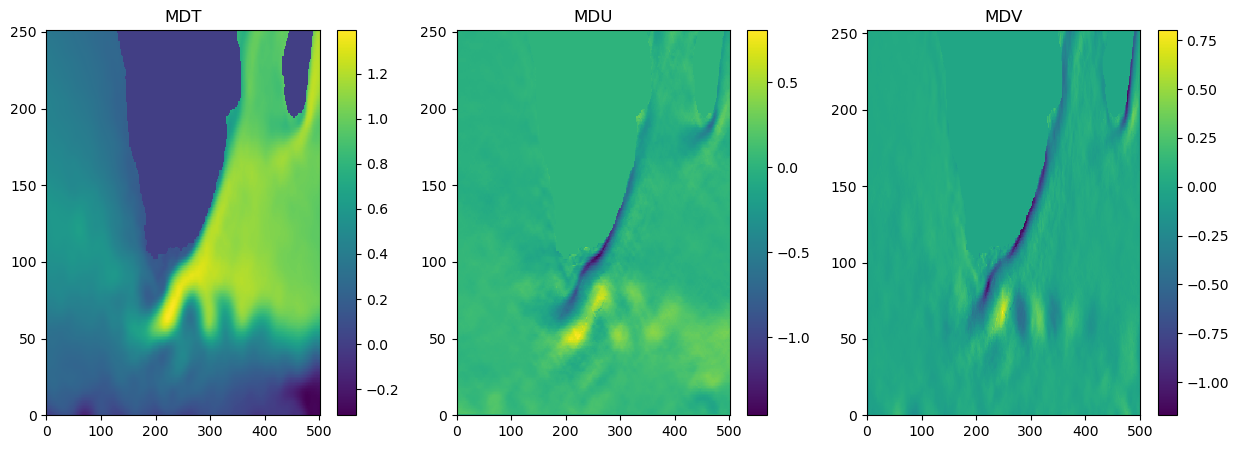

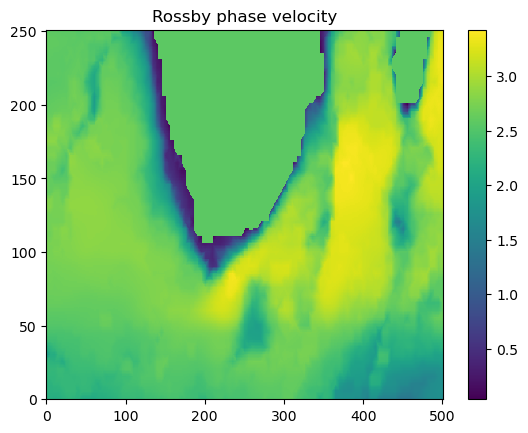

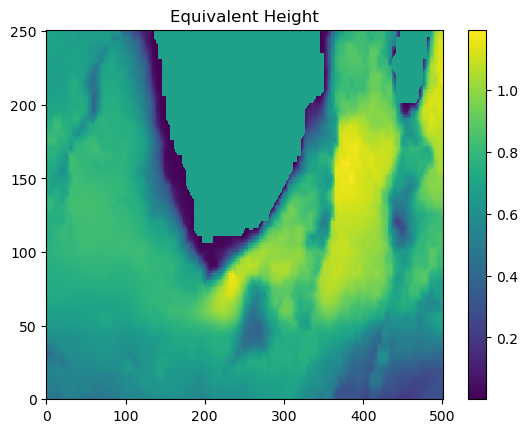

CFL condition for c= 3.4239231179659018
Model time-step 225


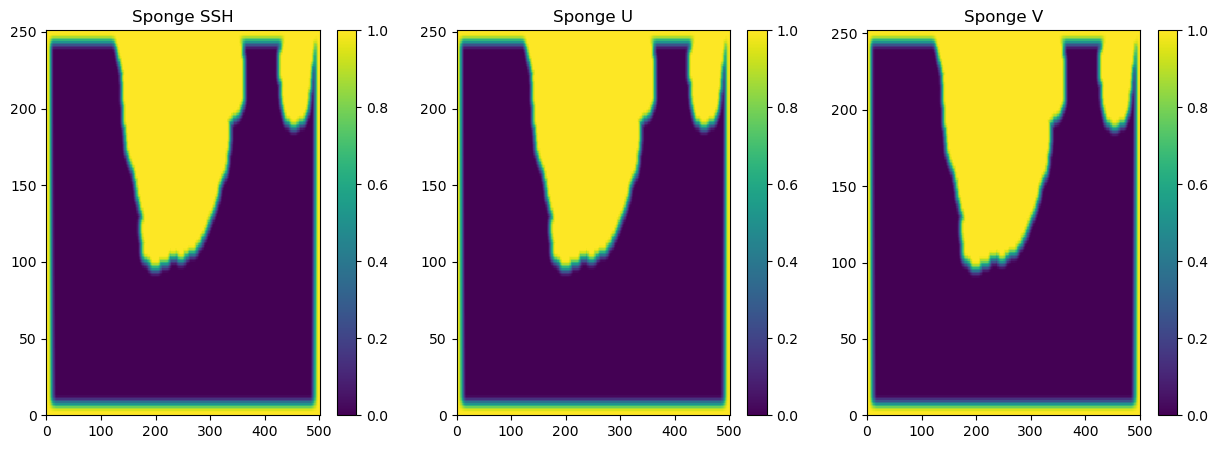

Creating SW model...
<class 'jax.numpy.float32'>
  - nx, ny, nl =  (501, 251, 1)
  - non-trivial mask provided


/home/anaconda/envs/massh/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


  - free-slip boundary condition
  - integration time step 2.250e+02


/home/flo/VarDyn/mapping/src/mod.py:3316: UserWarning: 
[SW model] nl=1 and h_wind is not set.
  The model's equivalent depth H = c²/g ≈ 0.70 m is used as the
  wind-stress denominator, but the physical mixed-layer depth is
  typically 50–200 m.  Wind forcing will be ~143× too large.
  → Set  param['h_wind'] = <mixed_layer_depth_m>  (e.g. 100.)
  self.model = model(params)


In [7]:
from src import mod as mod
Model = mod.Model(config,State)

Open, filter, and preprocess the observation datasets defined in the configuration.


In [8]:
from src import obs as obs
dict_obs = obs.Obs(config,State)

Observation information will be saved in dict_obs_SST_MW_AL_C2N_H2B_S3A_S3B_S6A_SWON_20250601_20250701_0_50_-45_-20_21600.txt

SST_MW:
super: OBS_L4
path: /data1/flo/ODYSSEA/SST_GLO_SST_L3S_NRT_OBSERVATIONS_010_010/cmems_obs-sst_glo_phy_l3s_pmw_P1D-m_202311/2025/06/*.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SST': 'adjusted_sea_surface_temperature'}
name_err: {}
subsampling: None
sigma_noise: 0.3
offset: None

--> 30 fields selected

AL:
super: OBS_SSH_NADIR
path: /data1/data/obs/level3/Alti_l3_cmems_NRT/al/*202506*.nc
name_time: time
name_lon: longitude
name_lat: latitude
name_var: {'SSH': 'sla_unfiltered'}
combine_var: None
synthetic_noise: None
varmax: 100.0
sigma_noise: None
add_mdt: None
substract_mdt: None
path_mdt: None
name_var_mdt: None
path_err: /data1/data/obs/level3/noise_v3/noise_alg.nc
name_var_err: {'lon': 'lon', 'lat': 'lat', 'var': 'noise'}
nudging_params_ssh: None
delta_t: None
velocity: None

[AL] Date filter: 30/51 files kept
READ AUX DATA FOR OBS E

Build the observation operators that interpolate model variables to the observation locations or grids.


In [9]:
from src import obsop as obsop
Obsop = obsop.Obsop(config,State,dict_obs,Model)

OBSOP_SSH: super: OBSOP_INTERP_L3
name_obs: None
name_var: SSH
write_op: True
path_save: ./H
compute_op: True
Npix: 4
mask_borders: False

OBSOP_SST: super: OBSOP_INTERP_L4
name_obs: None
name_var: SST
write_op: True
path_save: ./H
compute_op: True
mask_borders: False
interp_method: linear
gradients: False


super: OBSOP_INTERP_L3
name_obs: None
name_var: SSH
write_op: True
path_save: ./H
compute_op: True
Npix: 4
mask_borders: False

super: OBSOP_INTERP_L4
name_obs: None
name_var: SST
write_op: True
path_save: ./H
compute_op: True
mask_borders: False
interp_method: linear
gradients: False



Construct the reduced basis used as the 4DVar control-vector representation.


In [10]:
from src import basis as basis
Basis = basis.Basis(config,State)

super: BASIS_GAUSS3D
name_mod_var: sla
c_grid_var: None
compute_velocities: True
name_mod_u: u
name_mod_v: v
flux: True
facns: 3.0
facnlt: 3.0
sigma_D: 970
sigma_T: 25
sigma_Q: 0.03
fcor: 0.5
normalize_fact: True
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_BMaux
name_mod_var: sla
c_grid_var: None
compute_velocities: True
name_mod_u: u
name_mod_v: v
flux: False
facns: 1.0
facnlt: 2.0
npsp: 3.5
facpsp: 1.5
file_aux: ../../aux_files/aux_reduced_basis_BM.nc
lmin: 80
lmax: 1000.0
factdec: 7.5
tdecmin: 2.0
tdecmax: 40.0
facQ: 1
facQ_aux_path: None
l_largescale: 500
facQ_largescale: 1
file_depth: None
name_var_depth: {'lon': '', 'lat': '', 'var': ''}
depth1: 0.0
depth2: 30.0
path_background: None
var_background: None
norm_time: True
file_facQaux: None
name_var_facQaux: {'wavenumber': '', 'lon': '', 'lat': '', 'var': ''}

super: BASIS_GAUSS2D
name_mod_var: H
c_grid_var: None
com

Run the 4DVar inversion with the configured model, observations, operators, and basis.


super: INV_4DVAR
compute_test: False
freq_it_plot: 10
print_time: False
JAX_mem_fraction: None
path_init_4Dvar: None
restart_4Dvar: False
ftol: 5e-05
gtol: None
convergence_nit: 10
maxiter: 50
gradient_max_norm: 1000000000000.0
max_retries: 10
opt_method: L-BFGS-B
save_minimization: True
path_save_control_vectors: ./controls/VarDyn-SW
timestep_checkpoint: 6:00:00
sigma_R: None
sigma_B: None
prec: True
path_background: None
anomaly_from_bc: False

process observation operators
Processing observations at date 2025-06-01 00:00:00 for variable SST...
Processing observations at date 2025-06-02 00:00:00 for variable SST...
Processing observations at date 2025-06-03 00:00:00 for variable SST...
Processing observations at date 2025-06-04 00:00:00 for variable SST...
Processing observations at date 2025-06-05 00:00:00 for variable SST...
Processing observations at date 2025-06-06 00:00:00 for variable SST...
Processing observations at date 2025-06-07 00:00:00 for variable SST...
Processing obse

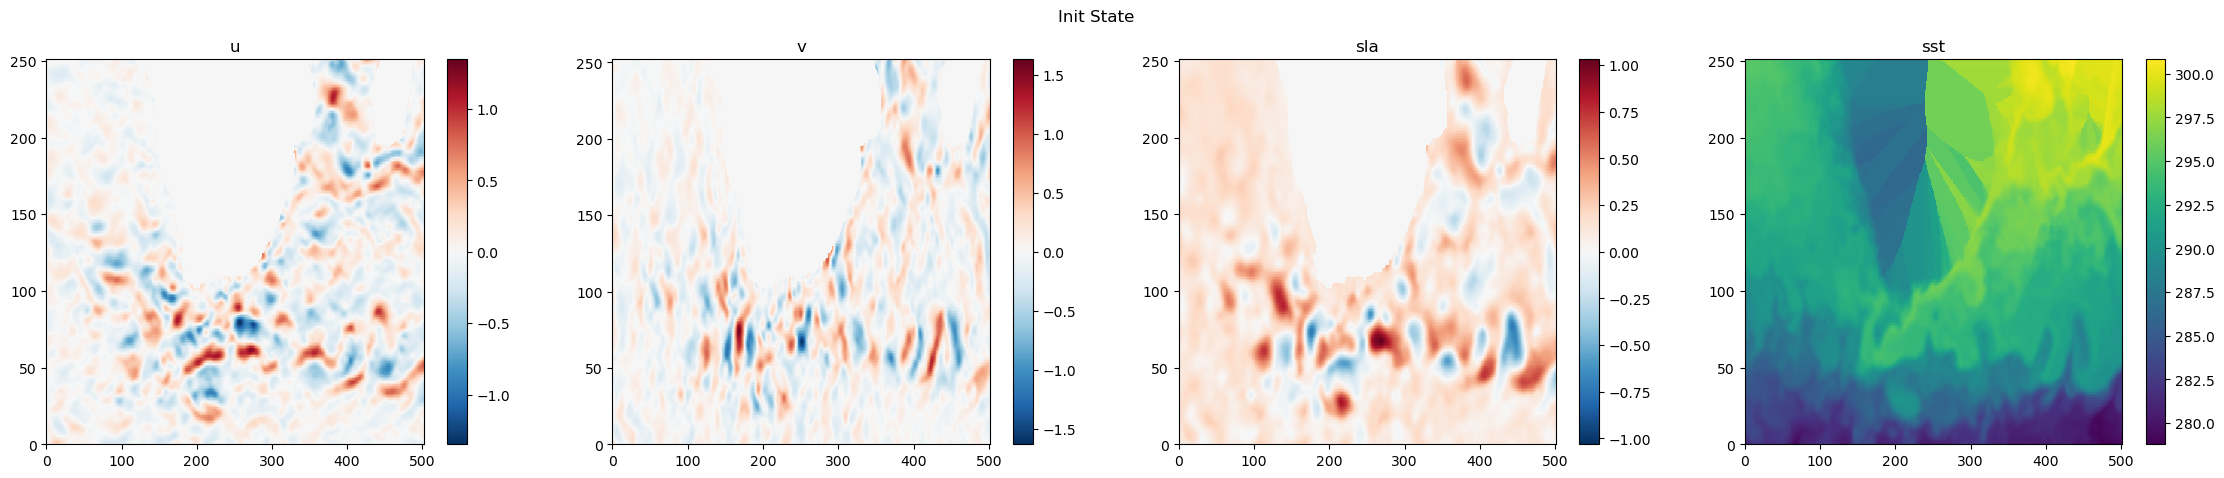

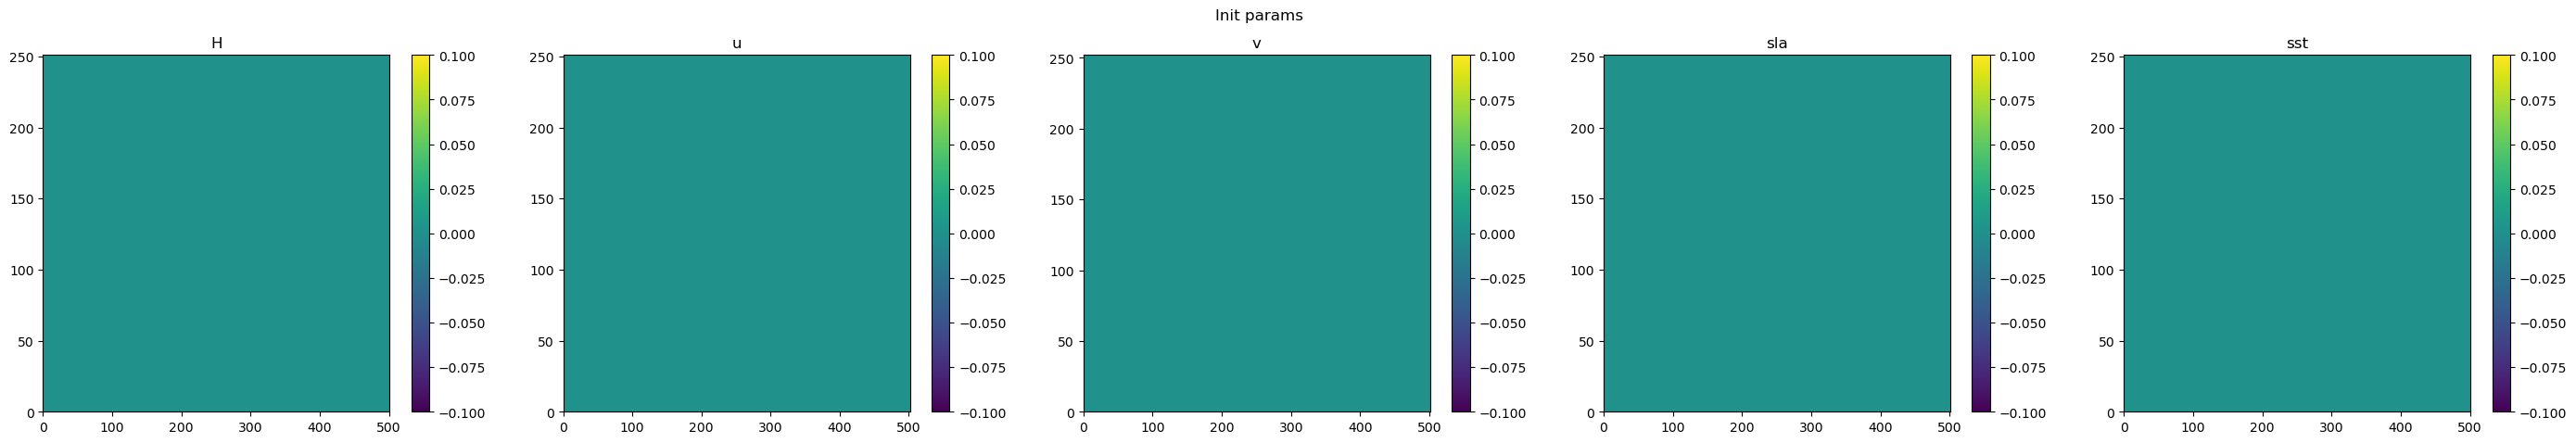

lambda=9.7E+02 nlocs=2.3E+02 tdec=2.5E+01 ntime=8.0E+00 Q=1.0E-02
reduced order: 15215871 --> 1832
 reduced factor: 8305
Setting Basis BMaux...
Computing Q
lambda=1.4E+03 nlocs=6.0E+00 tdec=2.0E+00 Q=1.0E-10
lambda=9.7E+02 nlocs=1.1E+01 tdec=1.3E+01 Q=1.4E-03
lambda=6.8E+02 nlocs=1.3E+01 tdec=9.7E+00 Q=2.3E-03
lambda=4.8E+02 nlocs=2.5E+01 tdec=9.0E+00 Q=3.5E-03
lambda=3.3E+02 nlocs=5.0E+01 tdec=8.5E+00 Q=3.6E-03
lambda=2.3E+02 nlocs=8.6E+01 tdec=6.5E+00 Q=2.7E-03
lambda=1.6E+02 nlocs=1.5E+02 tdec=3.7E+00 Q=1.6E-03
lambda=1.1E+02 nlocs=3.0E+02 tdec=2.5E+00 Q=1.2E-03
lambda=8.0E+01 nlocs=5.6E+02 tdec=2.2E+00 Q=7.6E-04
Computing Spatial components
Computing Time components
reduced order: 15215871 --> 619380
 reduced factor: 24
sigma_D=1.0E+03 nlocs=1.1E+02 Q=3.5E-02
reduced order: 15215871 --> 109
 reduced factor: 139595
lambda=1.0E+03 nlocs=2.1E+02 tdec=3.0E+00 ntime=3.4E+01 Q=1.7E-01
reduced order: 15215871 --> 7072
 reduced factor: 2151
lambda=9.7E+02 nlocs=2.3E+02 tdec=2.5E+01 ntime=8

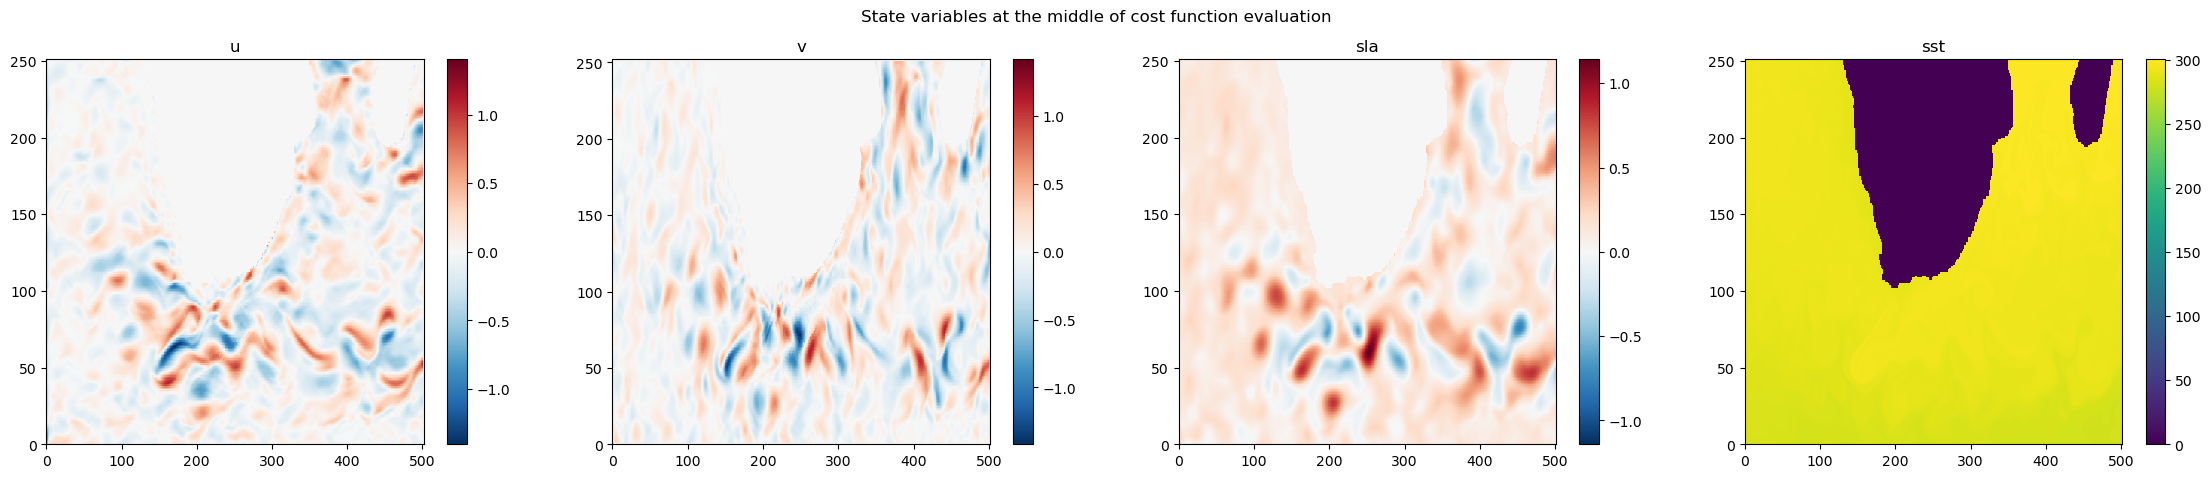

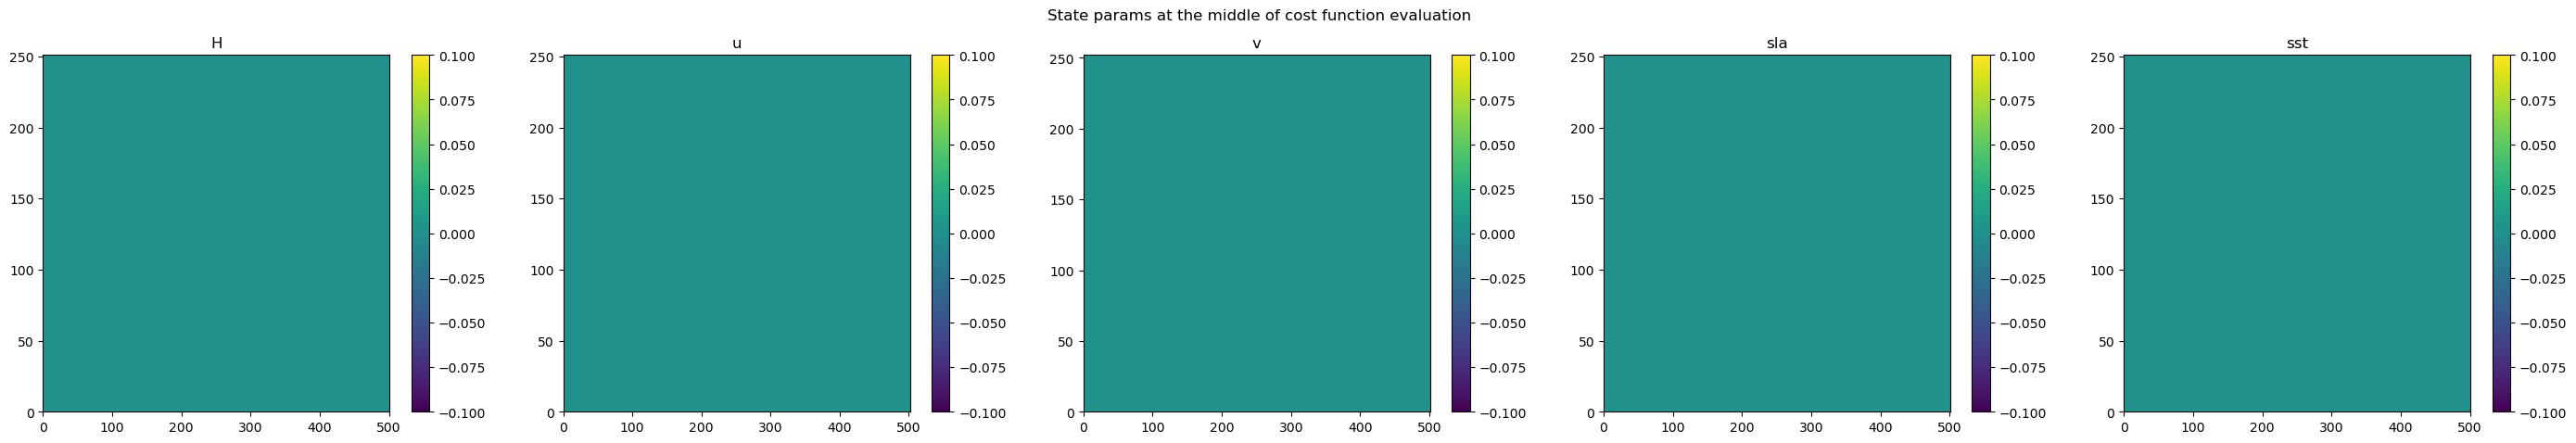

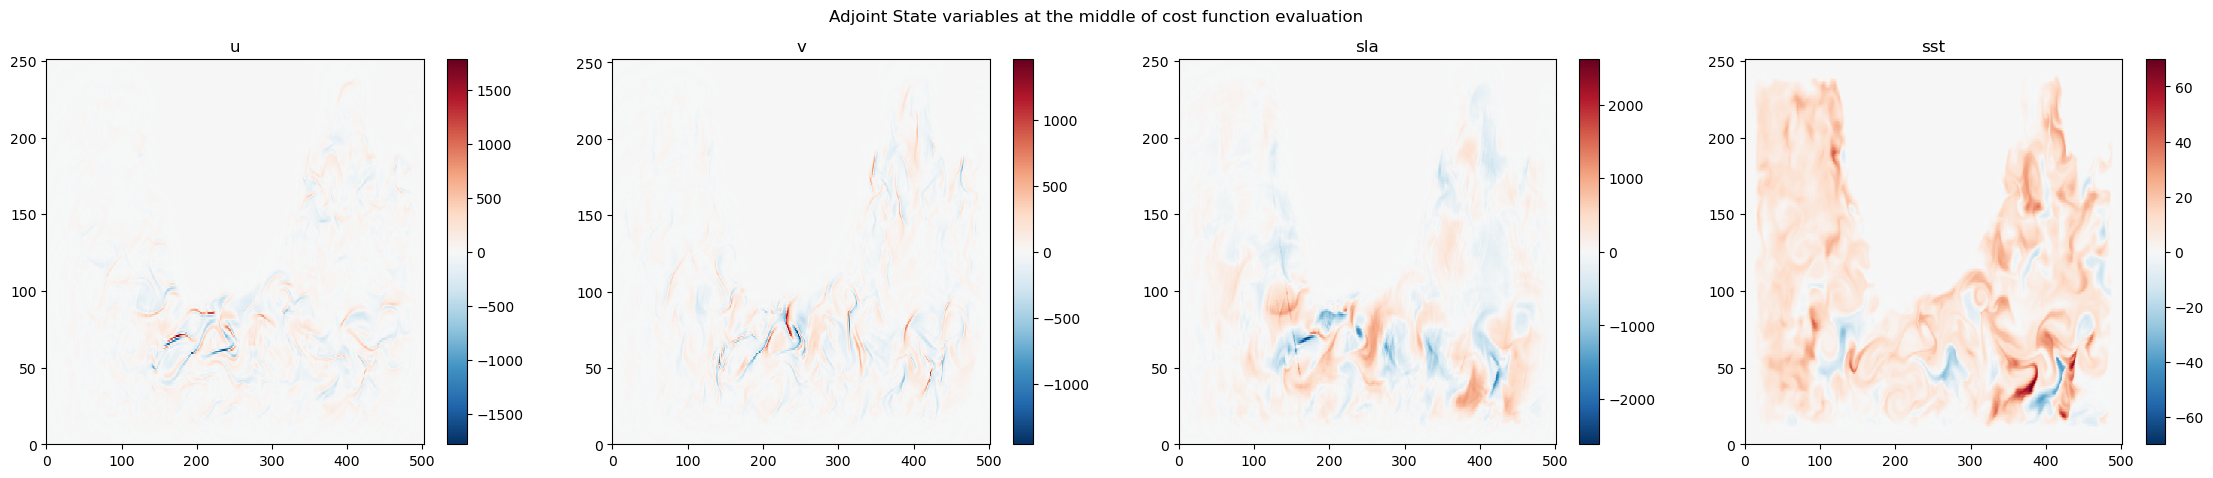

* iteration 1 computed in 1.14E+01 second:, x=0.00E+00, J=4.07E+06, G=2.87E+01, ftol=3.13E-13, gtol=5.51E-09
* iteration 2 computed in 1.01E+01 second:, x=-9.88E-07, J=3.78E+06, G=2.47E+01, ftol=7.13E-02, gtol=1.37E-01
* iteration 3 computed in 1.19E+01 second:, x=-7.04E-06, J=3.04E+06, G=1.94E+01, ftol=1.95E-01, gtol=2.18E-01
* iteration 4 computed in 9.64E+00 second:, x=-1.16E-05, J=2.57E+06, G=2.06E+01, ftol=1.56E-01, gtol=5.91E-02
* iteration 5 computed in 1.18E+01 second:, x=-2.20E-05, J=1.86E+06, G=1.83E+01, ftol=2.77E-01, gtol=1.11E-01
* iteration 6 computed in 9.97E+00 second:, x=-4.20E-05, J=1.34E+06, G=1.18E+01, ftol=2.79E-01, gtol=3.56E-01
* iteration 7 computed in 1.11E+01 second:, x=-4.90E-05, J=1.20E+06, G=1.05E+01, ftol=1.06E-01, gtol=1.13E-01
* iteration 8 computed in 1.11E+01 second:, x=-5.00E-05, J=1.13E+06, G=8.69E+00, ftol=5.96E-02, gtol=1.69E-01
* iteration 9 computed in 1.03E+01 second:, x=-5.07E-05, J=1.05E+06, G=8.07E+00, ftol=7.03E-02, gtol=7.17E-02


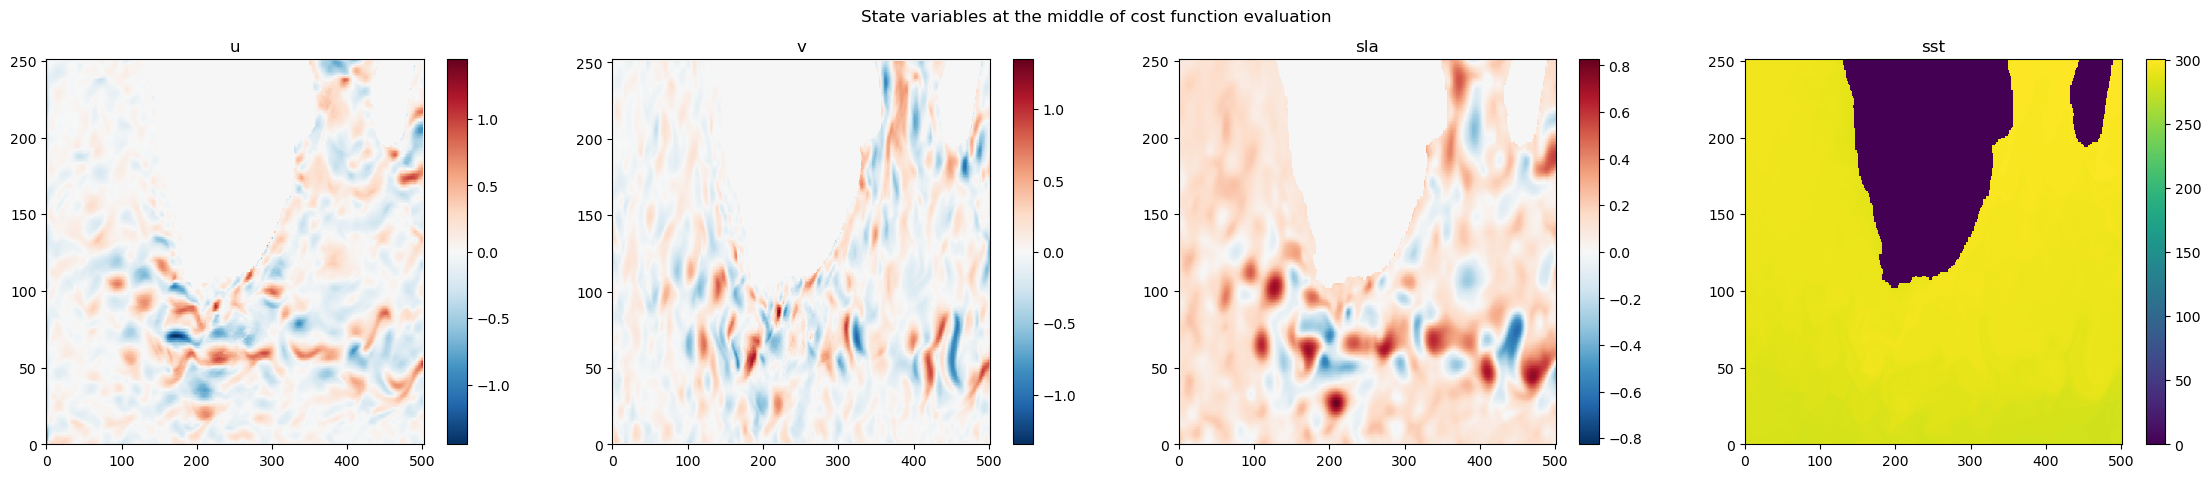

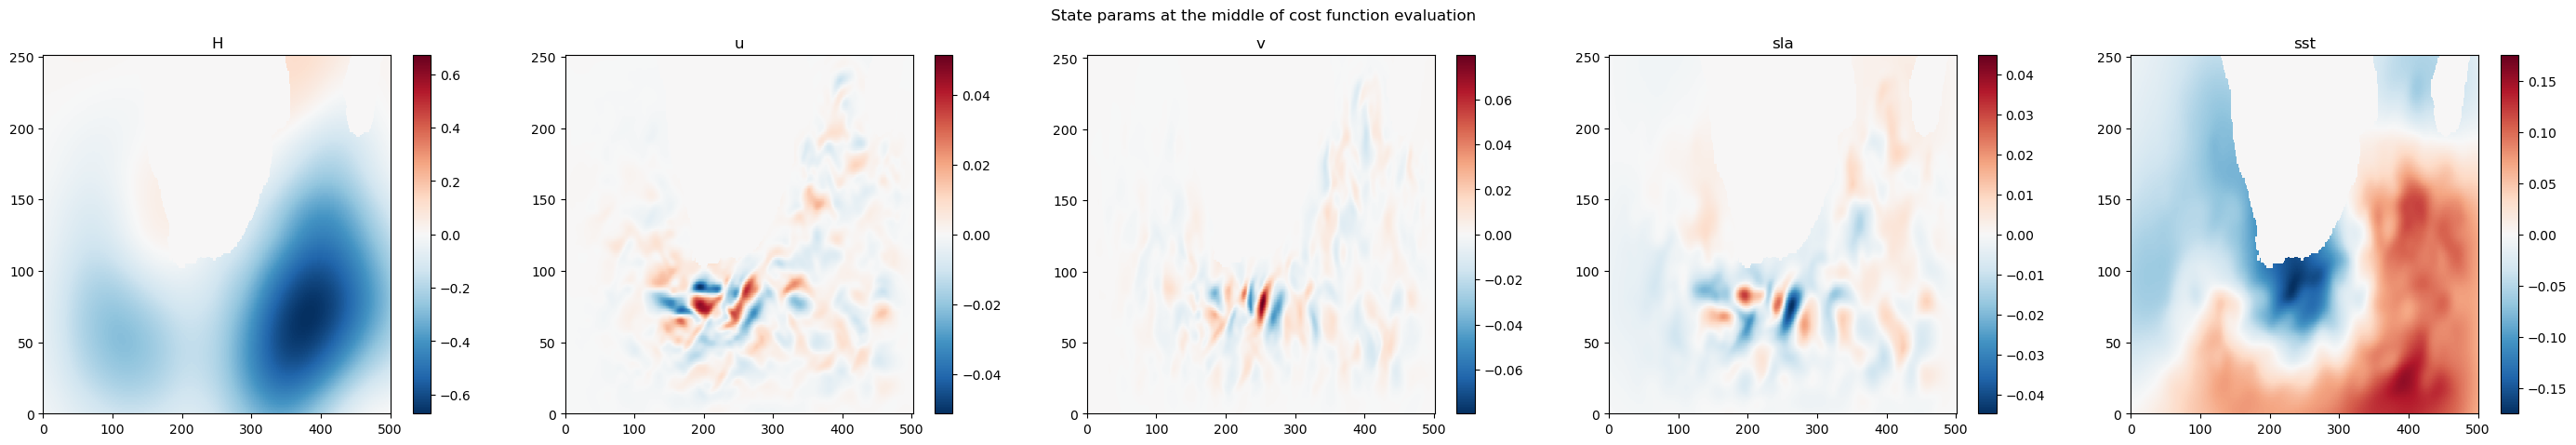

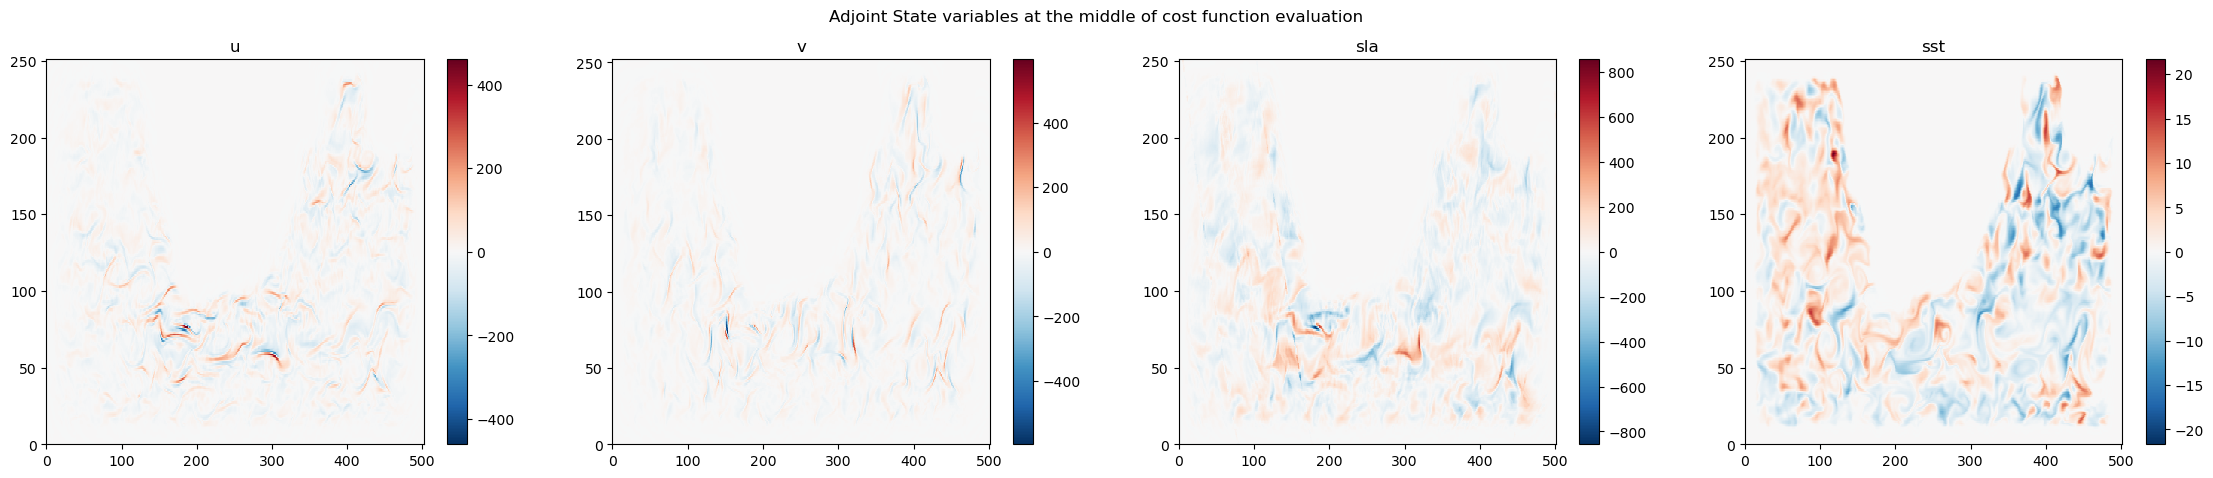

* iteration 10 computed in 1.50E+01 second:, x=-5.19E-05, J=9.53E+05, G=7.76E+00, ftol=8.89E-02, gtol=3.85E-02
* iteration 11 computed in 1.09E+01 second:, x=-5.27E-05, J=8.57E+05, G=7.03E+00, ftol=1.01E-01, gtol=9.40E-02
* iteration 12 computed in 1.03E+01 second:, x=-5.20E-05, J=7.92E+05, G=7.76E+00, ftol=7.64E-02, gtol=9.35E-02
* iteration 13 computed in 1.22E+01 second:, x=-5.39E-05, J=7.32E+05, G=5.68E+00, ftol=7.49E-02, gtol=2.67E-01
* iteration 14 computed in 9.86E+00 second:, x=-5.59E-05, J=7.08E+05, G=4.73E+00, ftol=3.25E-02, gtol=1.68E-01
* iteration 15 computed in 1.22E+01 second:, x=-6.37E-05, J=6.78E+05, G=4.62E+00, ftol=4.32E-02, gtol=2.22E-02
* iteration 16 computed in 1.01E+01 second:, x=-7.18E-05, J=6.56E+05, G=5.60E+00, ftol=3.24E-02, gtol=1.74E-01
* iteration 17 computed in 1.10E+01 second:, x=-7.59E-05, J=6.32E+05, G=4.24E+00, ftol=3.60E-02, gtol=2.42E-01
* iteration 18 computed in 1.14E+01 second:, x=-8.10E-05, J=6.13E+05, G=4.39E+00, ftol=3.09E-02, gtol=3.32E-02
*

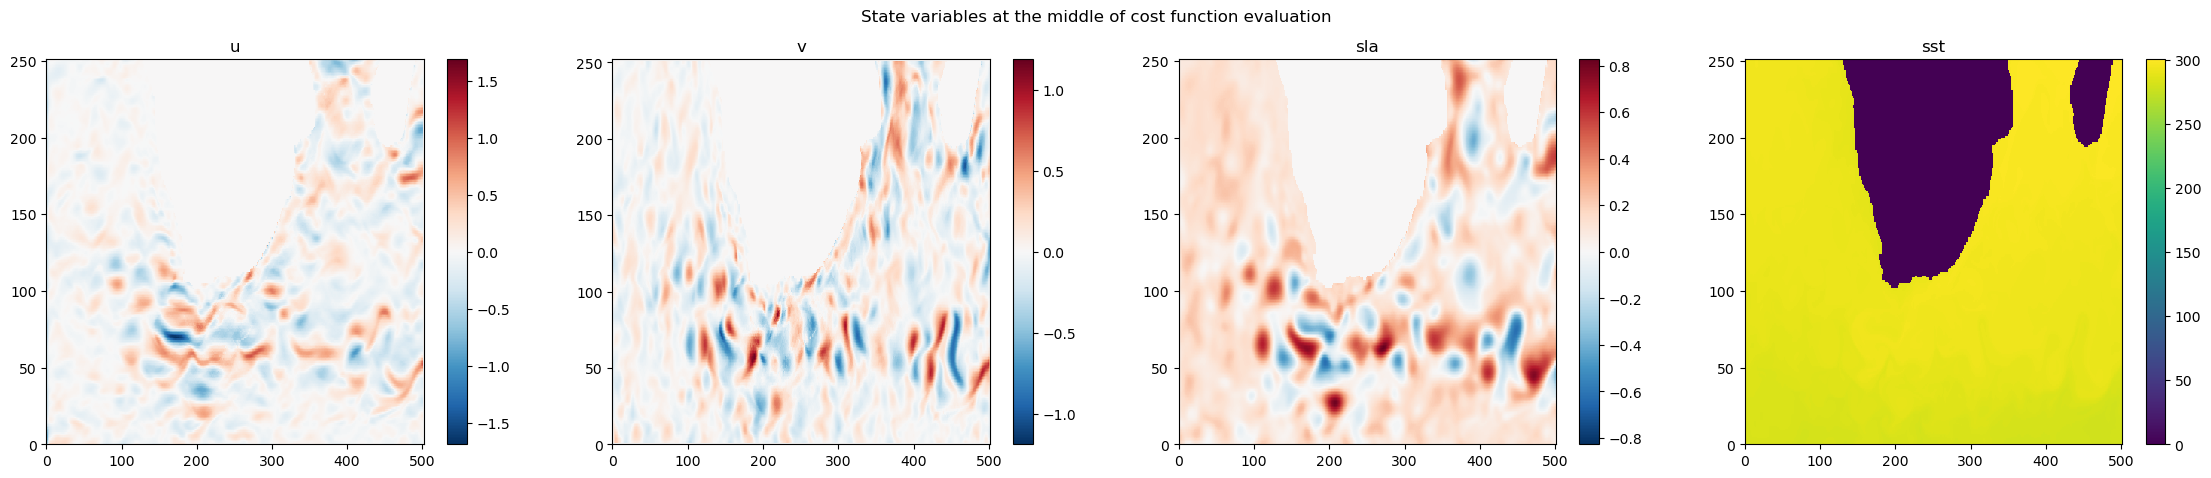

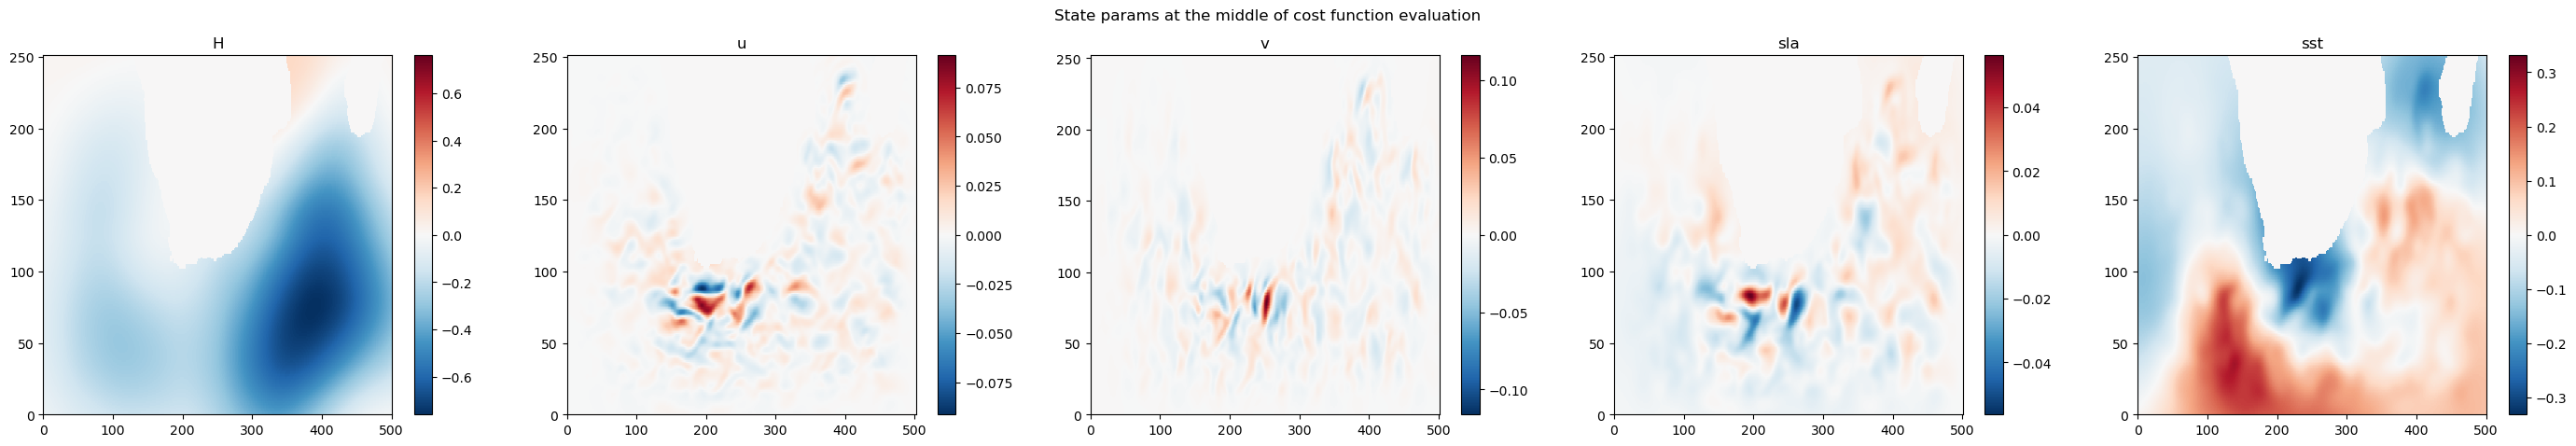

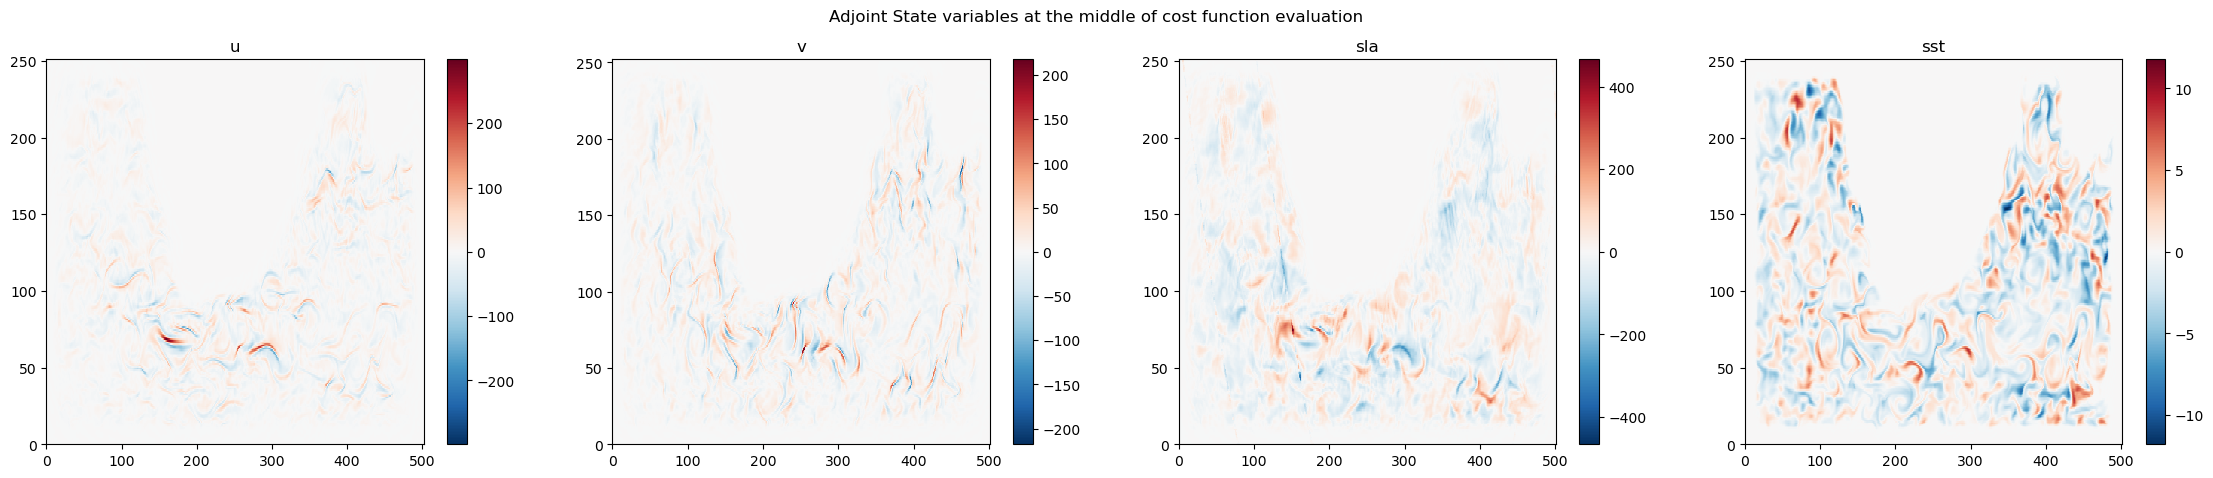

* iteration 20 computed in 1.50E+01 second:, x=-9.40E-05, J=5.70E+05, G=4.28E+00, ftol=4.10E-02, gtol=2.13E-02
* iteration 21 computed in 1.08E+01 second:, x=-9.93E-05, J=5.55E+05, G=4.42E+00, ftol=2.61E-02, gtol=3.12E-02
* iteration 22 computed in 1.03E+01 second:, x=-1.01E-04, J=5.44E+05, G=3.90E+00, ftol=2.16E-02, gtol=1.16E-01
* iteration 23 computed in 1.23E+01 second:, x=-1.07E-04, J=5.26E+05, G=3.49E+00, ftol=3.24E-02, gtol=1.05E-01
* iteration 24 computed in 9.67E+00 second:, x=-1.16E-04, J=5.10E+05, G=3.89E+00, ftol=3.00E-02, gtol=1.02E-01
* iteration 25 computed in 1.22E+01 second:, x=-1.28E-04, J=5.02E+05, G=4.39E+00, ftol=1.57E-02, gtol=1.15E-01
* iteration 26 computed in 9.97E+00 second:, x=-1.28E-04, J=4.92E+05, G=3.18E+00, ftol=2.03E-02, gtol=2.77E-01
* iteration 27 computed in 1.11E+01 second:, x=-1.32E-04, J=4.83E+05, G=3.20E+00, ftol=1.72E-02, gtol=6.41E-03
* iteration 28 computed in 1.12E+01 second:, x=-1.39E-04, J=4.74E+05, G=3.19E+00, ftol=1.90E-02, gtol=1.97E-03
*

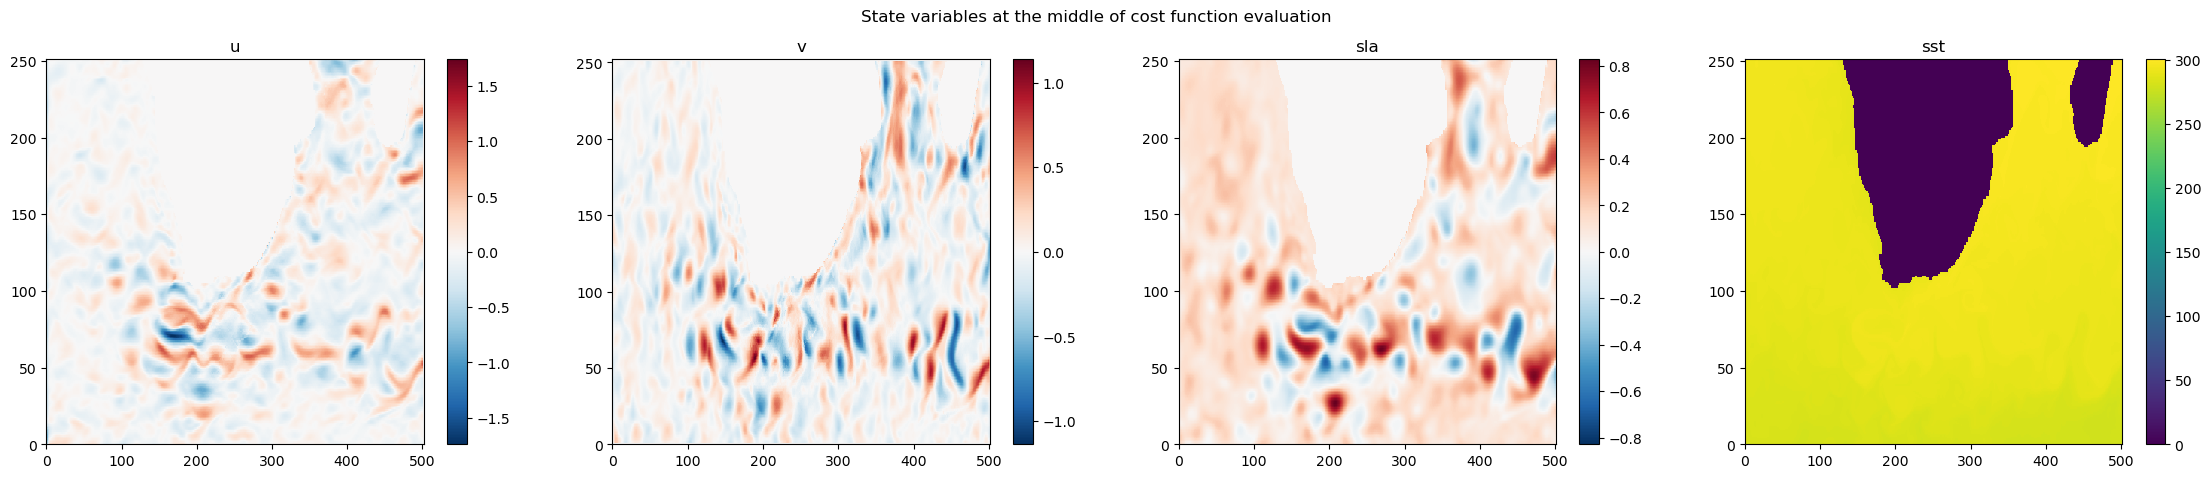

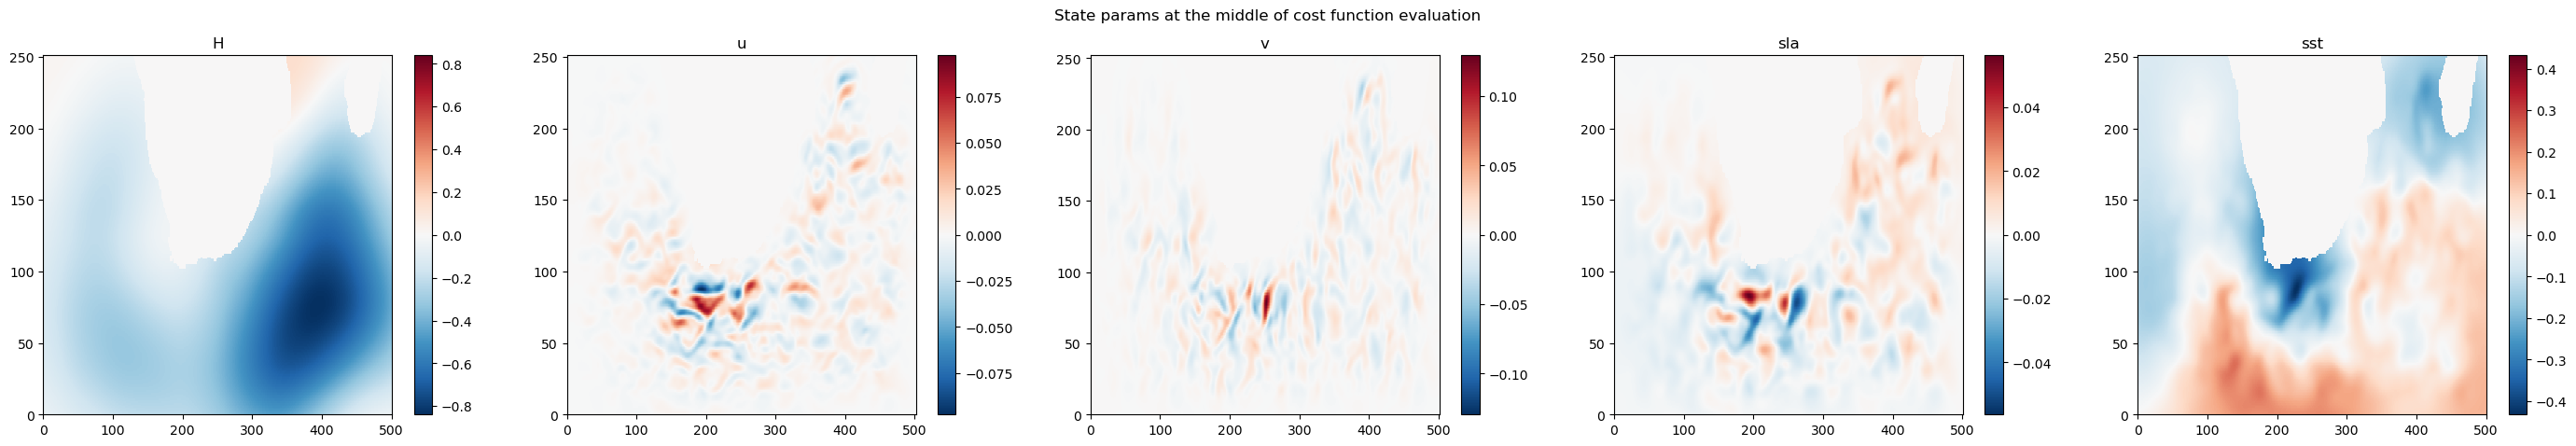

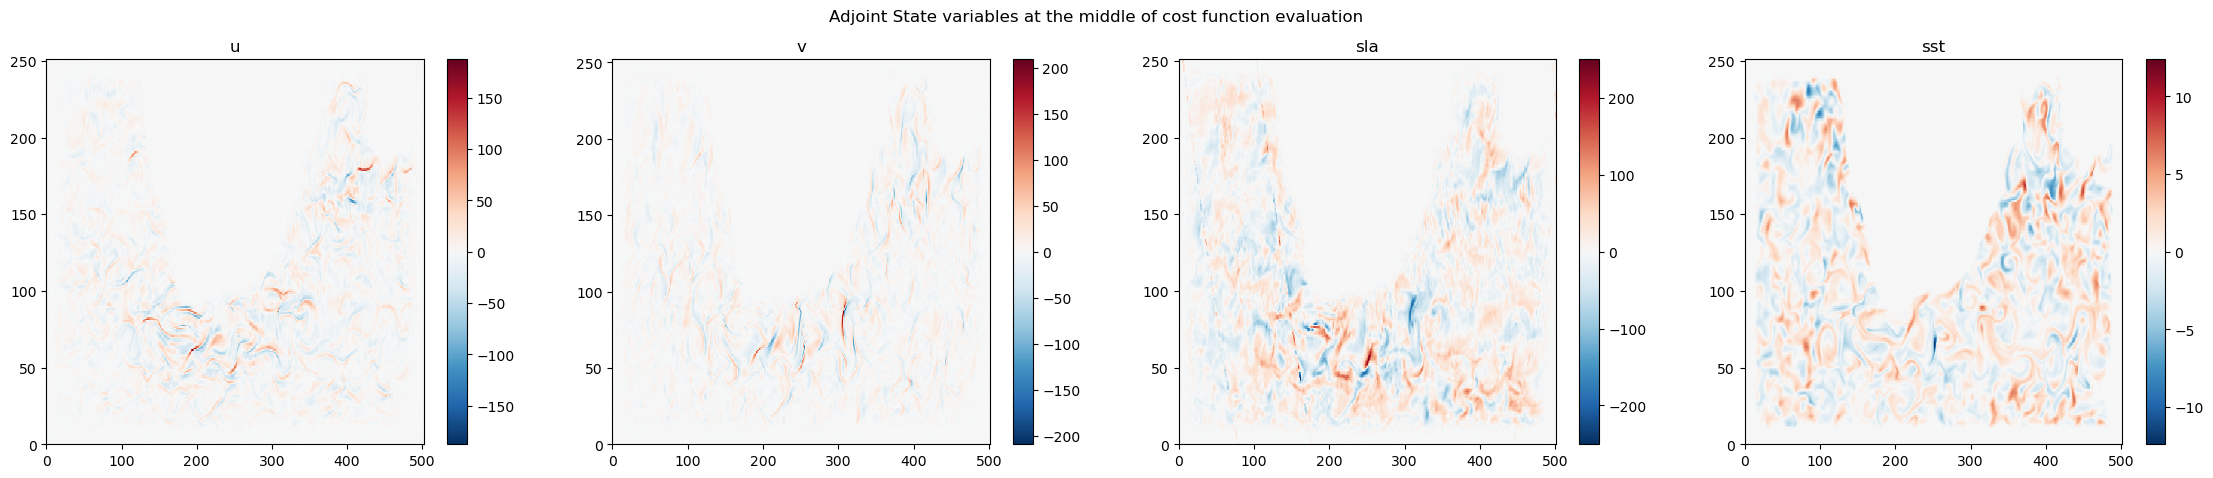

* iteration 30 computed in 1.50E+01 second:, x=-1.66E-04, J=4.52E+05, G=3.09E+00, ftol=2.56E-02, gtol=2.35E-01
* iteration 31 computed in 1.06E+01 second:, x=-1.69E-04, J=4.46E+05, G=2.79E+00, ftol=1.36E-02, gtol=9.88E-02
* iteration 32 computed in 1.04E+01 second:, x=-1.78E-04, J=4.36E+05, G=2.58E+00, ftol=2.18E-02, gtol=7.23E-02
* iteration 33 computed in 1.19E+01 second:, x=-1.90E-04, J=4.30E+05, G=3.85E+00, ftol=1.43E-02, gtol=3.29E-01
* iteration 34 computed in 9.82E+00 second:, x=-1.95E-04, J=4.22E+05, G=2.53E+00, ftol=1.83E-02, gtol=3.43E-01
* iteration 35 computed in 1.26E+01 second:, x=-1.98E-04, J=4.17E+05, G=2.39E+00, ftol=1.05E-02, gtol=5.55E-02
* iteration 36 computed in 9.58E+00 second:, x=-2.05E-04, J=4.11E+05, G=2.31E+00, ftol=1.48E-02, gtol=3.48E-02
* iteration 37 computed in 1.16E+01 second:, x=-2.25E-04, J=4.05E+05, G=3.03E+00, ftol=1.59E-02, gtol=2.40E-01
* iteration 38 computed in 1.06E+01 second:, x=-2.36E-04, J=3.98E+05, G=2.45E+00, ftol=1.60E-02, gtol=1.93E-01
*

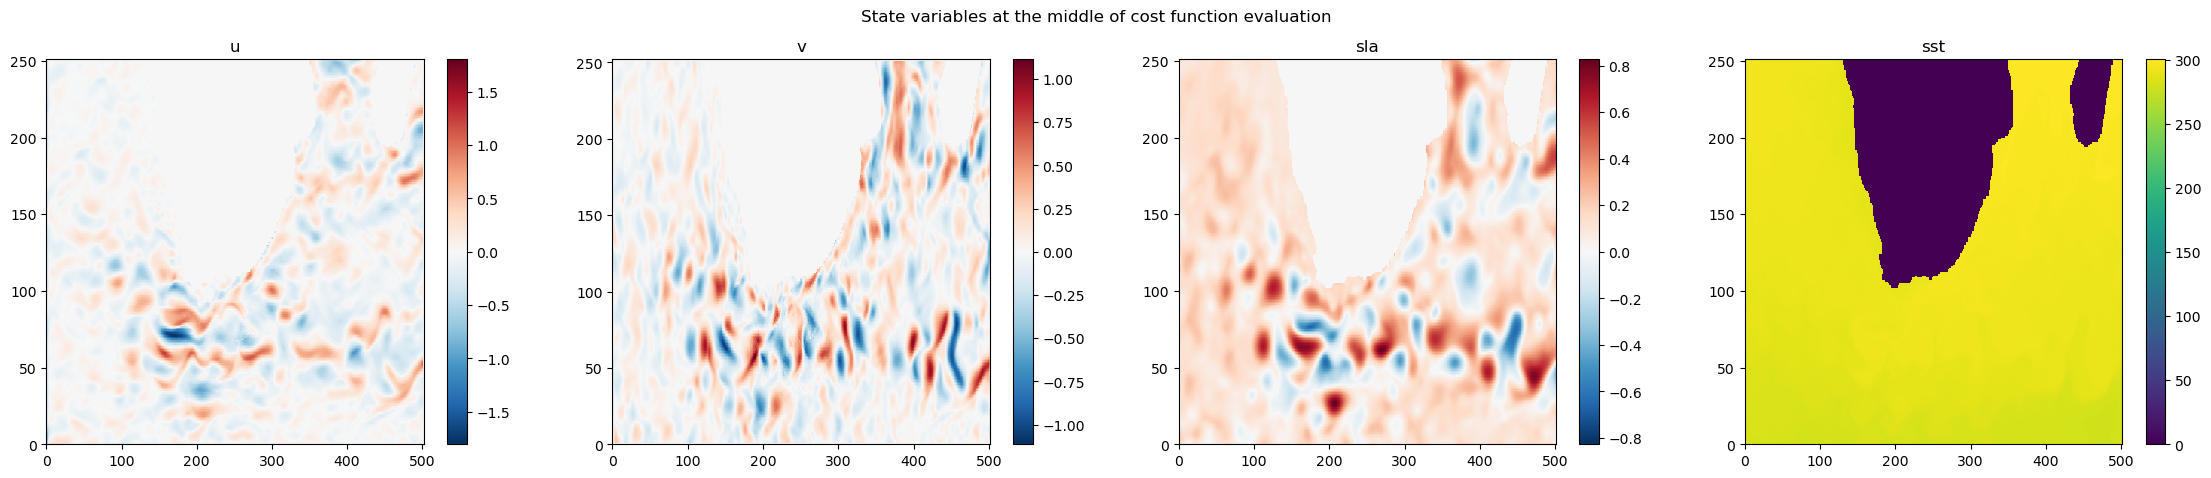

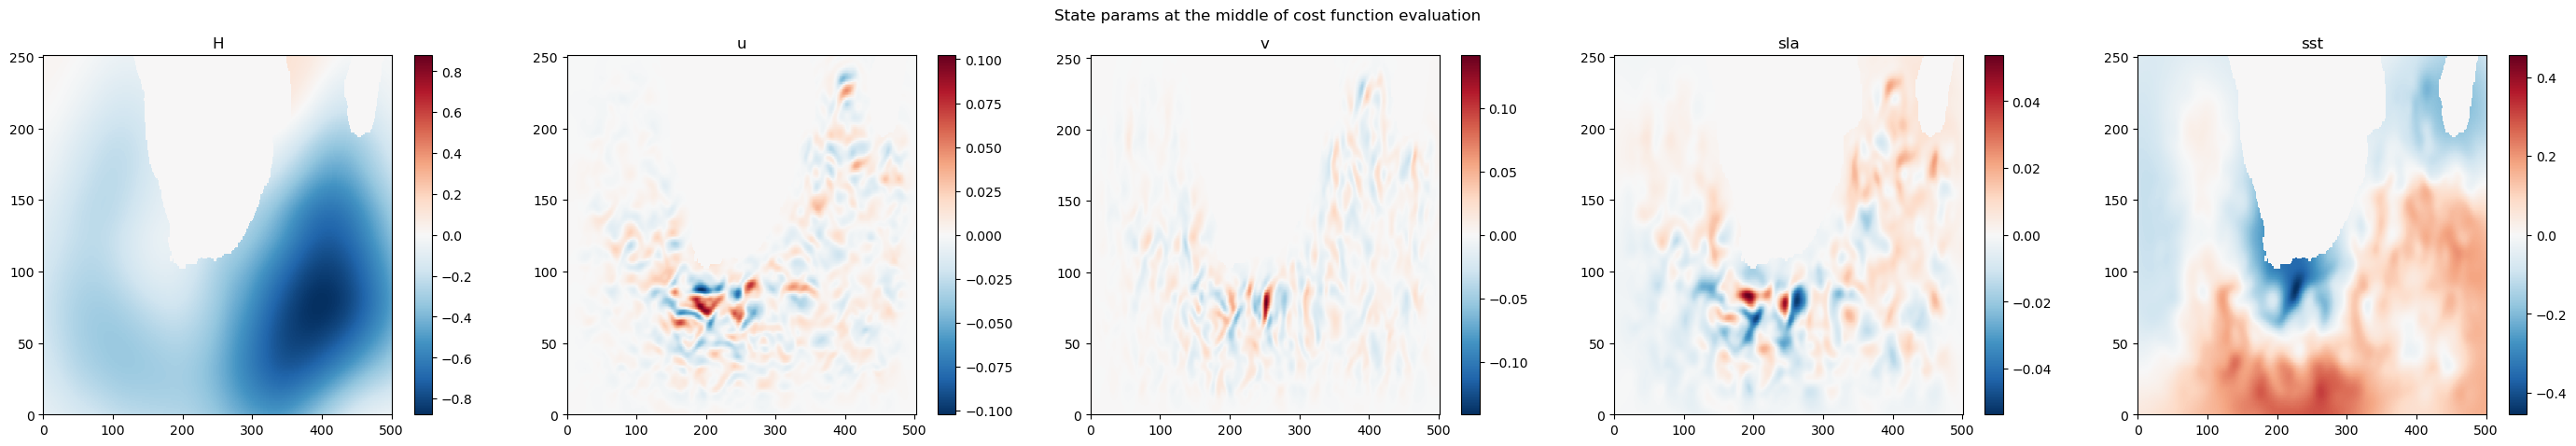

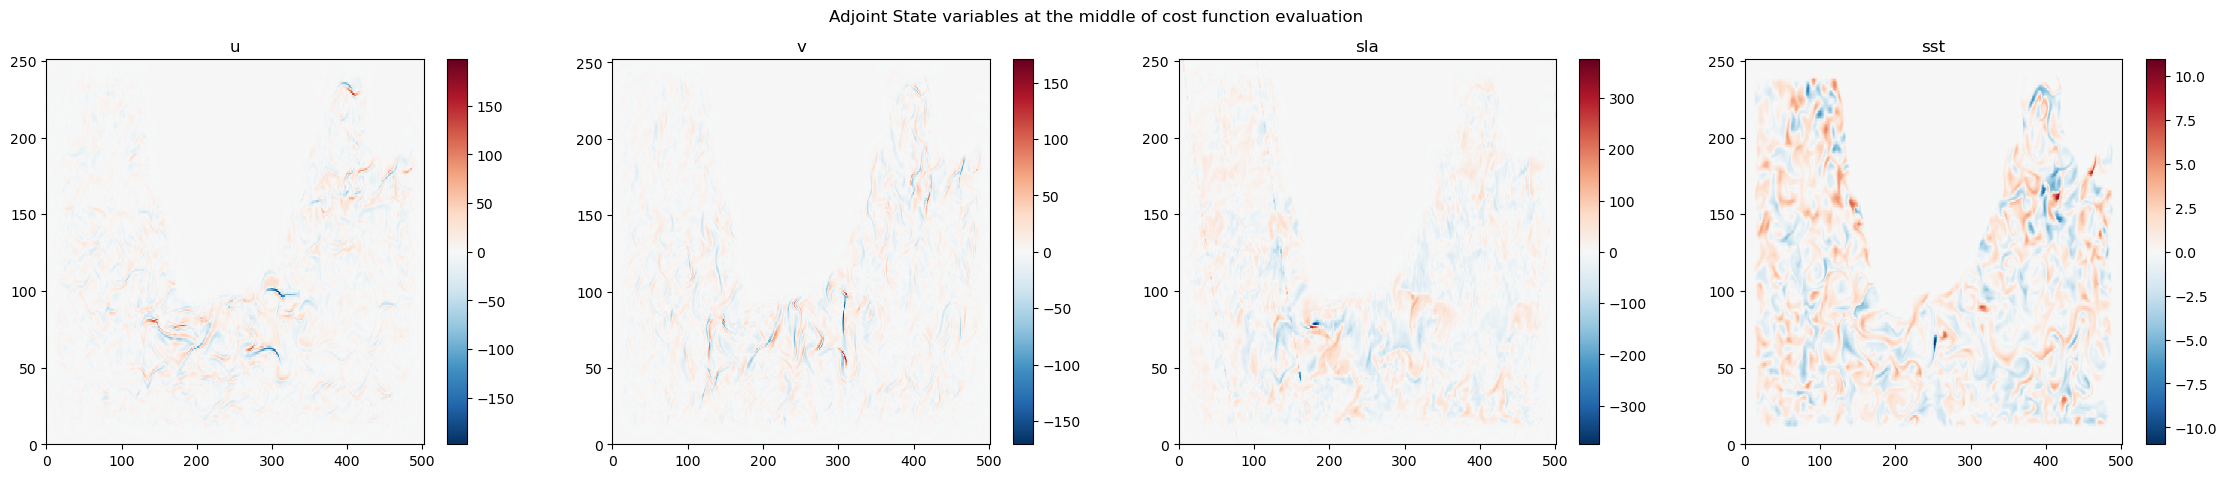

* iteration 40 computed in 1.50E+01 second:, x=-2.46E-04, J=3.88E+05, G=2.30E+00, ftol=1.56E-02, gtol=2.97E-02
* iteration 41 computed in 1.01E+01 second:, x=-2.58E-04, J=3.83E+05, G=2.63E+00, ftol=1.29E-02, gtol=1.26E-01
* iteration 42 computed in 1.10E+01 second:, x=-2.65E-04, J=3.78E+05, G=2.17E+00, ftol=1.30E-02, gtol=1.76E-01
* iteration 43 computed in 1.13E+01 second:, x=-2.78E-04, J=3.73E+05, G=2.18E+00, ftol=1.39E-02, gtol=7.65E-03
* iteration 44 computed in 1.00E+01 second:, x=-2.84E-04, J=3.70E+05, G=2.55E+00, ftol=7.34E-03, gtol=1.44E-01
* iteration 45 computed in 1.25E+01 second:, x=-2.89E-04, J=3.67E+05, G=2.21E+00, ftol=7.78E-03, gtol=1.33E-01
* iteration 46 computed in 9.59E+00 second:, x=-3.02E-04, J=3.62E+05, G=1.90E+00, ftol=1.37E-02, gtol=1.40E-01
* iteration 47 computed in 1.20E+01 second:, x=-3.10E-04, J=3.59E+05, G=2.02E+00, ftol=8.97E-03, gtol=5.98E-02
* iteration 48 computed in 1.00E+01 second:, x=-3.22E-04, J=3.54E+05, G=1.93E+00, ftol=1.30E-02, gtol=4.68E-02
*

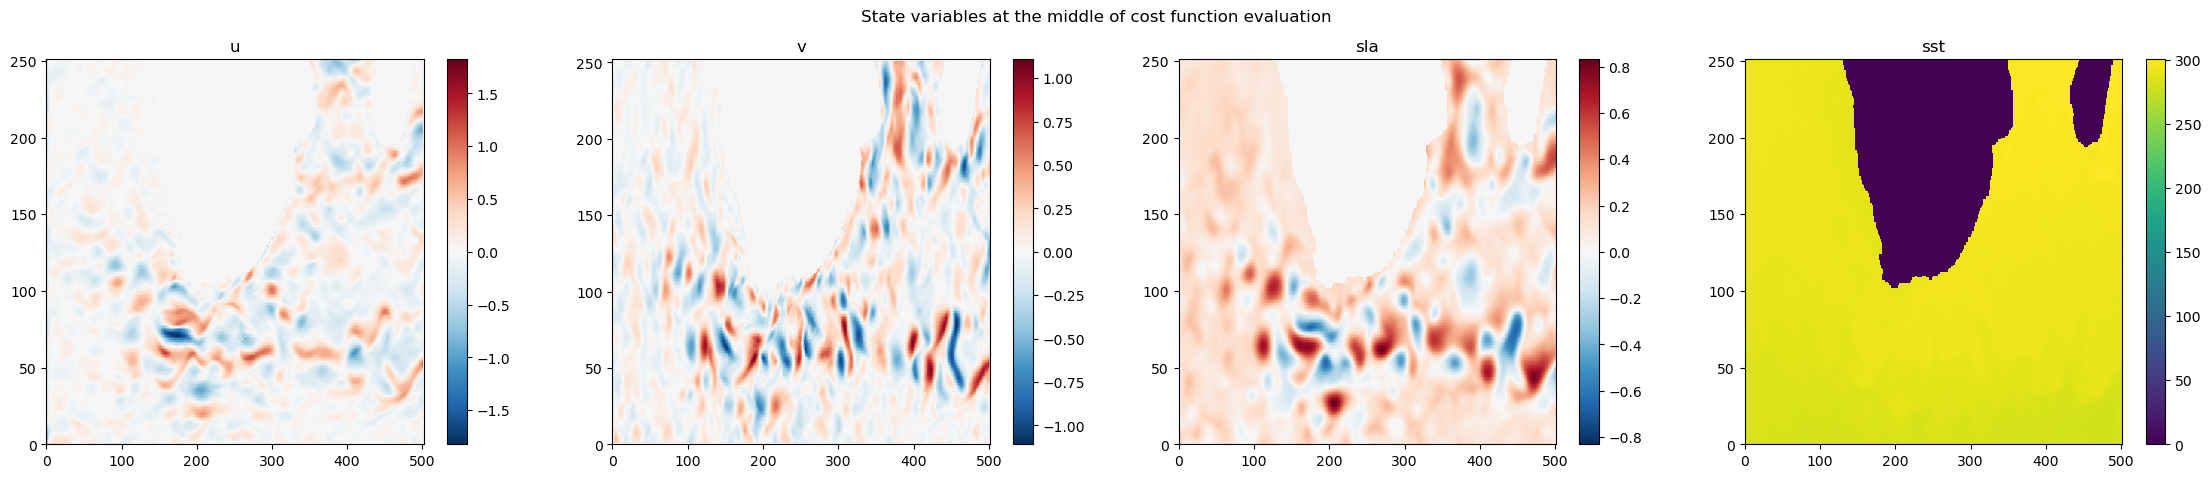

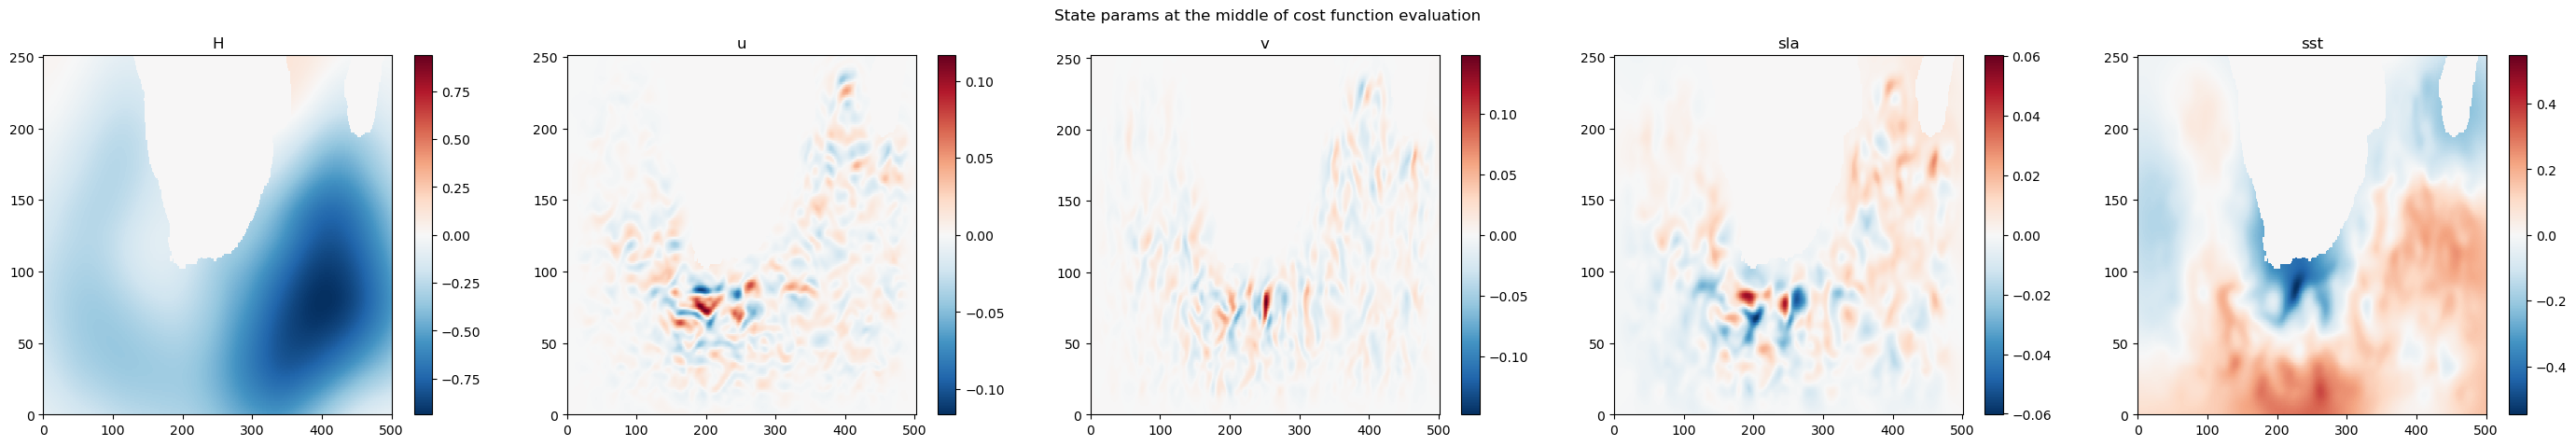

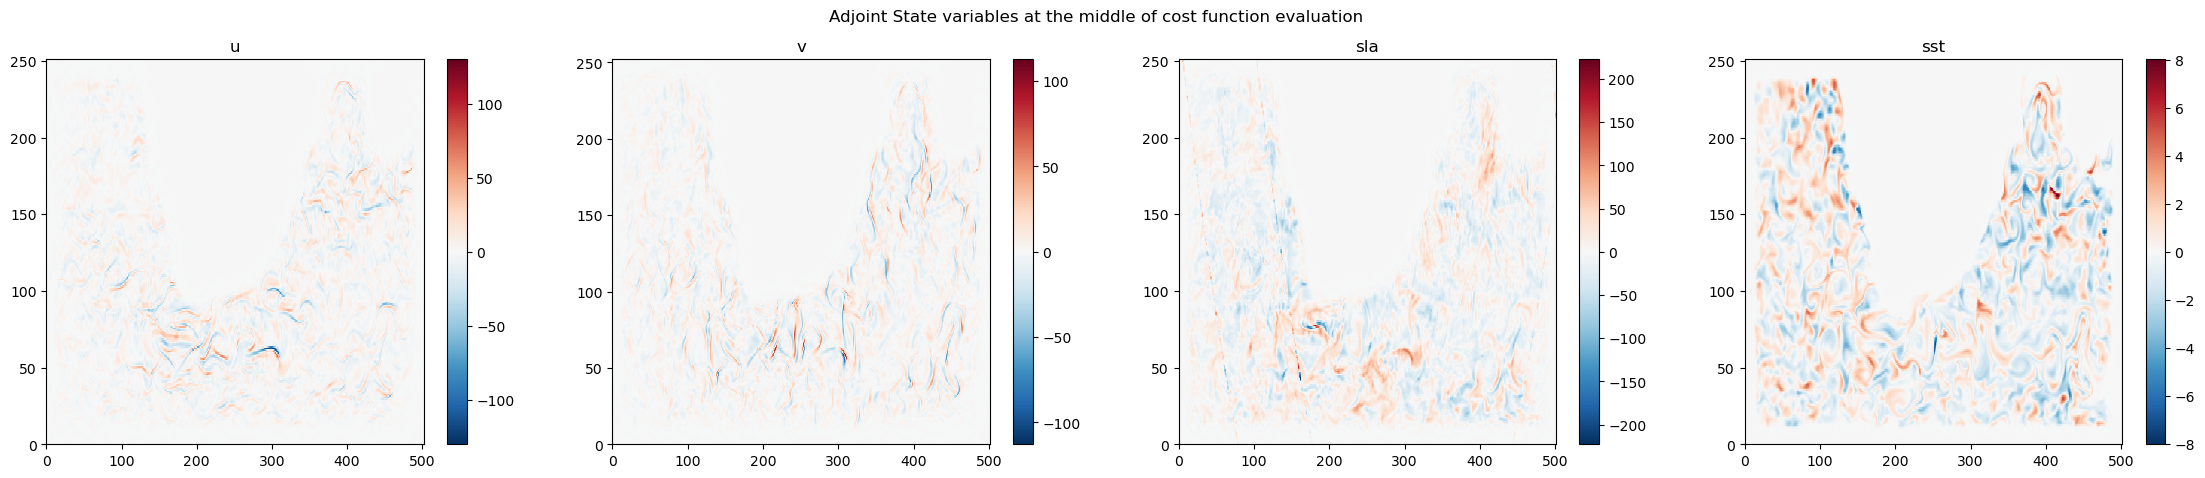

* iteration 50 computed in 1.66E+01 second:, x=-3.36E-04, J=3.48E+05, G=2.00E+00, ftol=9.36E-03, gtol=1.11E-01
* iteration 51 computed in 9.98E+00 second:, x=-3.43E-04, J=3.45E+05, G=2.12E+00, ftol=8.96E-03, gtol=5.85E-02

Is the minimization successful? False

Final cost function value: 345277.2858800359

Number of iterations: 50

*** Saving trajectory ***




In [11]:
from src import inv as inv
inv.Inv(config,State,Model,dict_obs=dict_obs,Obsop=Obsop,Basis=Basis,gpu_device=NUM_GPU)  